In [1]:
import sympy as sy
import numpy as np
import matplotlib.pyplot as plt, mpld3
import matplotlib as mpl
# %matplotlib widget
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
# mpld3.enable_notebook()
import scipy

if mpl.rcParams["figure.facecolor"] == "black":
    mpl.rcParams["figure.facecolor"] = (41/255, 45/255, 62/255, 1)
    mpl.rcParams["axes.facecolor"] = (41/255, 45/255, 62/255, 1)


In [2]:
%%html
<style>
.cell-output-ipywidget-background {
   background-color: transparent !important;
}
.jp-OutputArea-output {
   background-color: transparent;
}  
.mpld3-text {
   fill: black !important;
}
.mpld3-axesbg {
   fill: #ffffff00 !important
}
</style>

# L03

## PySINDy Lorenz system

$$x' = \sigma (y-x)$$
$$y'= x(\rho - z) - y$$
$$ z' = xy - \beta z $$

In [3]:
def lorenz(t, vars, sigma, rho, beta):
    x, y, z = vars
    dx = sigma * (y - x)
    dy = x*(rho-z)-y
    dz = x*y - beta*z
    return np.array([dx, dy, dz])

In [4]:
dt = 0.002
ts = np.arange(0,100, dt)
t_span = (0,100)
y0 = np.array([1,2,3])
constants = np.array([10, 28, 2.667])

In [5]:
sol = scipy.integrate.solve_ivp(fun=lorenz, t_span=t_span,t_eval=ts, y0=y0, args=(constants))

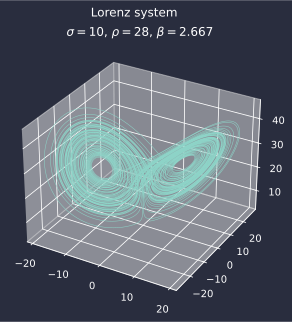

In [6]:
x, y, z = sol.y

ax = plt.figure().add_subplot(projection='3d')

plt.suptitle("Lorenz system")
plt.title(r"$\sigma = 10$, $\rho = 28$, $\beta = 2.667$")
ax.plot(x,y,z, lw=0.5)
